In [1]:
## weekly registration test
import sys
print(sys.executable)
import os
os.environ["ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"] = "16" # set the number of threads for ITK to use
from glob import glob
import wslPath

import ants
import matplotlib.pyplot as plt
import numpy as np
from skimage import io # Using scikit-image for potential multi-page support
from tqdm import tqdm
from pathlib import Path
import tifffile 

/mnt/d/Codex_folder/molecular_tracking/.venv/bin/python


In [6]:
## list of function to write
## - [] crop images to much smaller FoV to speed up computing
##      - only do like 256*256*41?
## - [] get date from file name and group them in weeks (Monday to Sunday)
## - [] find the medoid image of that week (it's likely the middle date or the first day since all images are aligned to it)

def crop_images(image_path,crop_size=256):
    image_path = wslPath.to_posix(image_path)
    image_path = Path(image_path)
    image_array = io.imread(image_path)
    print(f"now processing {image_path.name}")    
    z,y,x = image_array.shape
    crop_size = crop_size
    crop_image_array = image_array[:,y//2-crop_size//2:y//2+crop_size//2,x//2-crop_size//2:x//2+crop_size//2]
    parent_dir = image_path.parent
    output_dir = parent_dir / f"crop_{crop_size}"
    output_fname = output_dir / f"{image_path.name.split('.tif')[0]}_crop_{crop_size}.tif"
    output_dir.mkdir(parents=True, exist_ok=True)
    io.imsave(output_fname, crop_image_array, check_contrast=False)
    print(f"Output file saved: {output_fname.name}")


In [7]:
## loop through images and make cropped images

folder_path = r"D:\_data\_newAAV_2026\weekly_registration_test"
folder_path = wslPath.to_posix(folder_path)
file_list = sorted(glob(f"{folder_path}/*.tif"))
file_list = [f for f in file_list if 'SyN' not in f] # in case there are already registered files
file_list = [f for f in file_list if 'masks' not in f] # in case there are already registered ROI mask files
file_list = [f for f in file_list if 'dark' not in f] # in case there is a dark value image

_ = [crop_images(wslPath.to_windows(f)) for f in file_list]


now processing 20260511_G.tif
Output file saved: 20260511_G_crop_256.tif
now processing 20260511_R.tif
Output file saved: 20260511_R_crop_256.tif
now processing 20260512_G.tif
Output file saved: 20260512_G_crop_256.tif
now processing 20260512_R.tif
Output file saved: 20260512_R_crop_256.tif
now processing 20260513_G.tif
Output file saved: 20260513_G_crop_256.tif
now processing 20260513_R.tif
Output file saved: 20260513_R_crop_256.tif
now processing 20260514_G.tif
Output file saved: 20260514_G_crop_256.tif
now processing 20260514_R.tif
Output file saved: 20260514_R_crop_256.tif
now processing 20260515_G.tif
Output file saved: 20260515_G_crop_256.tif
now processing 20260515_R.tif
Output file saved: 20260515_R_crop_256.tif
now processing 20260518_G.tif
Output file saved: 20260518_G_crop_256.tif
now processing 20260518_R.tif
Output file saved: 20260518_R_crop_256.tif
now processing 20260519_G.tif
Output file saved: 20260519_G_crop_256.tif
now processing 20260519_R.tif
Output file saved: 20

In [8]:
## remove all file with SyN, masks average
cropped_folder_path = Path(r"D:\_data\_newAAV_2026\weekly_registration_test\crop_256")
cropped_folder_path = wslPath.to_posix(cropped_folder_path)
file_list = glob(f"{cropped_folder_path}/*.tif")
file_list
## remove all file with SyN, masks average
for file in file_list:
    if "SyN" in file or "masks" in file or "average" in file:
        os.remove(file)
file_list = glob(f"{cropped_folder_path}/*.tif")
file_list

['/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260511_G_crop_256.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260511_R_crop_256.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260512_G_crop_256.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260512_R_crop_256.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260513_G_crop_256.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260513_R_crop_256.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260514_G_crop_256.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260514_R_crop_256.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260515_G_crop_256.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260515_R_crop_256.tif',
 '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260518_G_crop_256.tif',
 '/mnt/d/_data/_newAAV_2026/week

In [9]:
from pathlib import Path
from datetime import datetime
from collections import defaultdict

def group_files_by_week(file_list):
    week_groups = defaultdict(list)

    for file_path in file_list:
        filename = Path(file_path).name
        date_str = filename.split("_")[0]   # "20260511"

        date = datetime.strptime(date_str, "%Y%m%d").date()

        # Monday of that week
        week_start = date.fromordinal(date.toordinal() - date.weekday())

        week_groups[week_start].append(file_path)

    # Sort weeks chronologically and rename as week1, week2, ...
    week_dict = {}
    for i, week_start in enumerate(sorted(week_groups), start=1):
        week_dict[f"week{i}"] = sorted(week_groups[week_start])

    return week_dict

In [10]:
## cropped file list
cropped_file_list = sorted(glob(f"{folder_path}/crop_256/*.tif"))
cropped_file_list = [f for f in cropped_file_list if 'average' not in f]
cropped_file_list = [f for f in cropped_file_list if 'SyN' not in f]

week_dict = []
week_dict = group_files_by_week(cropped_file_list)
week_dict

# ## now try week_dic for real images

# folder_path = r"D:\_data\_newAAV_2026\weekly_registration_test"
# folder_path = wslPath.to_posix(folder_path)
# file_list = sorted(glob(f"{folder_path}/*.tif"))
# file_list = [f for f in file_list if 'SyN' not in f] # in case there are already registered files
# file_list = [f for f in file_list if 'masks' not in f] # in case there are already registered ROI mask files
# file_list = [f for f in file_list if 'dark' not in f] # in case there is a dark value image
# week_dict = group_files_by_week(file_list)
# week_dict

{'week1': ['/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260511_G_crop_256.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260511_R_crop_256.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260512_G_crop_256.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260512_R_crop_256.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260513_G_crop_256.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260513_R_crop_256.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260514_G_crop_256.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260514_R_crop_256.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260515_G_crop_256.tif',
  '/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260515_R_crop_256.tif'],
 'week2': ['/mnt/d/_data/_newAAV_2026/weekly_registration_test/crop_256/20260518_G_crop_256.tif',
  

In [31]:
## after grouping the files by week, we can do registration within each week to find the medoid image of that week, 
## and then do registration across weeks to find the global medoid image.

## first, need to find the mode of the images in each week, which is the image that has the smallest average distance to all other images in that week.
## then, we can register the medoid images of each week to find the global medoid

## we can use ants.math.image_similarity to calculate the similarity between two images, and use that as the distance metric to find the medoid image.


week_n = 4


week_list = week_dict[f"week{week_n}"]
week_list = [f for f in week_list if '_R' in f] # use the cropped images for registration

import itertools

similarity_dict = {}
## loop through all pairs of images in the week and calculate their similarity, including self-similarity (which should be the highest/lowestes in MI)
for a, b in itertools.combinations_with_replacement(week_list, 2):
    # print(a.split('/')[-1], b.split('/')[-1])
    a_numpy = io.imread(a)
    b_numpy = io.imread(b)
    a_ants = ants.from_numpy(a_numpy)
    b_ants = ants.from_numpy(b_numpy)
    ## apply quick affine registration first before assessing correlation
    if a == b: # in case that we are comparing the same image, we don't need to register it to itself
        ## the similarity of the same image is fixed to -1, we can skip the computation
        similarity = -1.0
    else:
        warped_parms = ants.registration(fixed=a_ants, moving=b_ants, type_of_transform='Affine')
        warped_b_ants = warped_parms['warpedmovout']
        # similarity = ants.image_similarity(a_ants, b_ants, metric_type='MattesMutualInformation')
        similarity = ants.image_similarity(a_ants, warped_b_ants, metric_type='Correlation') ## convert to positive similarity, higher is more similar

    print(f"Similarity between {a.split('/')[-1]} and {b.split('/')[-1]}: {similarity}")
    similarity_dict[(a, b)] = similarity



Similarity between 20260601_R_crop_256.tif and 20260601_R_crop_256.tif: -1.0
Similarity between 20260601_R_crop_256.tif and 20260602_R_crop_256.tif: -0.9079674482345581
Similarity between 20260601_R_crop_256.tif and 20260603_R_crop_256.tif: -0.8451454639434814
Similarity between 20260602_R_crop_256.tif and 20260602_R_crop_256.tif: -1.0
Similarity between 20260602_R_crop_256.tif and 20260603_R_crop_256.tif: -0.8612918853759766
Similarity between 20260603_R_crop_256.tif and 20260603_R_crop_256.tif: -1.0


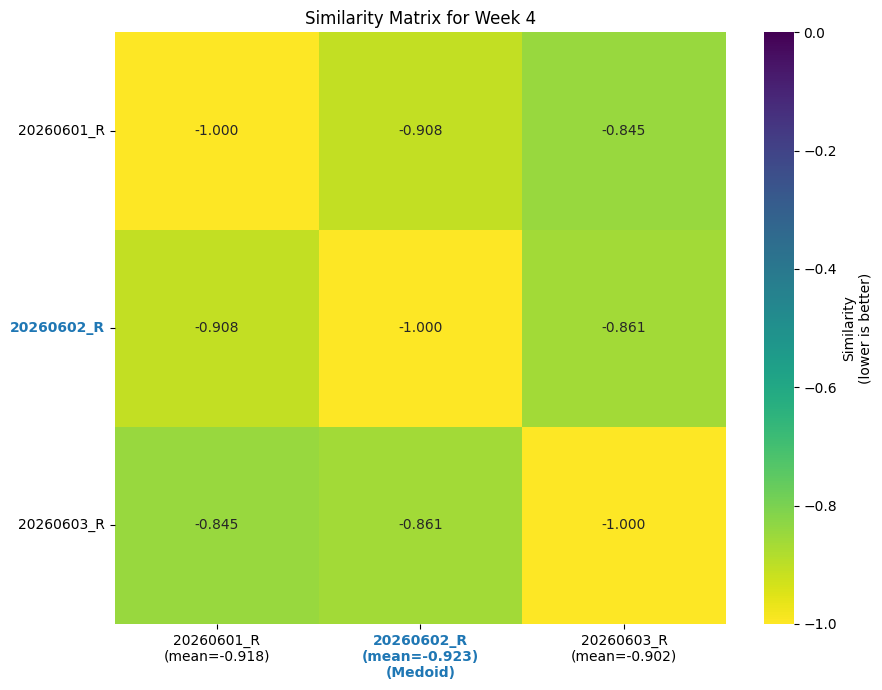

Medoid image for week 4: 20260602_R_crop_256.tif


In [32]:
## plot simiarity matrix as a heatmap, with the file names as the x and y labels
import seaborn as sns
import pandas as pd
similarity_matrix = np.zeros((len(week_list), len(week_list)))
for i, a in enumerate(week_list):
    for j, b in enumerate(week_list):
        if i == j:
            similarity_matrix[i, j] = similarity_dict[(a, b)]
        elif (a, b) in similarity_dict:
            similarity_matrix[i, j] = similarity_dict[(a, b)]
        elif (b, a) in similarity_dict:
            similarity_matrix[i, j] = similarity_dict[(b, a)]
        else:
            similarity_matrix[i, j] = 0.0

similarity_df = pd.DataFrame(similarity_matrix, index=[Path(f).name.split('_crop')[0] for f in week_list], columns=[Path(f).name.split('_crop')[0] for f in week_list])

plt.figure(figsize=(9, 7))
sns.heatmap(similarity_df, annot=True, fmt=".3f", cmap='viridis_r', cbar_kws={'label': 'Similarity\n(lower is better)'},vmin=-1,vmax=0)
plt.title(f"Similarity Matrix for Week {week_n}")
mean_similarity = np.nanmean(similarity_matrix, axis=1)
# plt.xticks(ticks=np.arange(len(week_list))+0.5, labels=[f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})" for i, f in enumerate(week_list)], rotation=0, ha='center')
plt.yticks(rotation=0)
## highlight the medoid image (the one with the highest average similarity to all other images) by changing the color of its label
medoid_index = np.nanargmin(mean_similarity)
xtick_labels = [
    f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})"
    if i != medoid_index
    else f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})\n(Medoid)"
    for i, f in enumerate(week_list)
]
plt.xticks(
    ticks=np.arange(len(week_list)) + 0.5,
    labels=xtick_labels,
    rotation=0,
    ha='center'
)
ax = plt.gca()
for idx, label in enumerate(ax.get_xticklabels()):
    if idx == medoid_index:
        label.set_color('C0')
        label.set_fontweight('bold')
for idx, label in enumerate(ax.get_yticklabels()):
    if idx == medoid_index:
        label.set_color('C0')
        label.set_fontweight('bold')
plt.tight_layout()
plt.show()


## find the most similar image to all other images, which is the medoid image of that week
similarity_sums = np.nansum(similarity_matrix, axis=1)
medoid_index = np.nanargmin(similarity_sums) # find the one with the smallest average distance to all other images
medoid_image = week_list[medoid_index]
print(f"Medoid image for week {week_n}: {Path(medoid_image).name}")



In [33]:
## perform SyN registration for all images in that week to the medoid image, and save the registered images in the same folder with "_SyN" suffix
medoid_ants = ants.from_numpy(io.imread(medoid_image))
for image_path in week_list:
    if image_path == medoid_image:
        ## directly copy the medoid image to the output folder with "_SyN" suffix
        output_path = Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"
        io.imsave(output_path, io.imread(image_path), check_contrast=False)
        print(f"Medoid image copied to: {output_path.name}")
        ## same for green channel
        output_path_g = Path(image_path.replace('_R', '_G')).parent / f"{Path(image_path.replace('_R', '_G')).stem}_SyN.tif"
        io.imsave(output_path_g, io.imread(image_path.replace('_R', '_G')), check_contrast=False)
        print(f"Medoid G channel image copied to: {output_path_g.name}")        
        continue
    moving_ants = ants.from_numpy(io.imread(image_path))
    reg = ants.registration(fixed=medoid_ants, moving=moving_ants, type_of_transform='SyN')
    registered_ants = reg['warpedmovout']
    registered_numpy = registered_ants.numpy()
    output_path = Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"
    io.imsave(output_path, registered_numpy.astype(np.uint16), check_contrast=False)
    print(f"Registered image saved: {output_path.name}")
    ## do the same for the G channel
    moving_ants_g = ants.from_numpy(io.imread(image_path.replace('_R', '_G')))
    ## apply transform to the G channel using the same transform as the R channel
    registered_ants_g = ants.apply_transforms(fixed=medoid_ants, moving=moving_ants_g, transformlist=reg['fwdtransforms'])
    registered_numpy_g = registered_ants_g.numpy()
    output_path_g = Path(image_path.replace('_R', '_G')).parent / f"{Path(image_path.replace('_R', '_G')).stem}_SyN.tif"
    io.imsave(output_path_g, registered_numpy_g.astype(np.uint16), check_contrast=False)
    print(f"Registered G channel image saved: {output_path_g.name}")

## make an average image of all registered images in that week, and save it as "weekX_average.tif"
registered_images = []
for image_path in week_list:
    if image_path == medoid_image:
        registered_images.append(io.imread(image_path))
    else:
        registered_images.append(io.imread(Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"))
average_image = np.nanmean(registered_images, axis=0)
output_path = Path(folder_path) /"crop_256" / f"week{week_n}_average.tif"
io.imsave(output_path, average_image.astype(np.uint16), check_contrast=False)
print(f"Average image saved: {output_path.name}")

Registered image saved: 20260601_R_crop_256_SyN.tif
Registered G channel image saved: 20260601_G_crop_256_SyN.tif
Medoid image copied to: 20260602_R_crop_256_SyN.tif
Medoid G channel image copied to: 20260602_G_crop_256_SyN.tif
Registered image saved: 20260603_R_crop_256_SyN.tif
Registered G channel image saved: 20260603_G_crop_256_SyN.tif
Average image saved: week4_average.tif


[GUI INFO] : WRITING LOG OUTPUT TO /home/hunglinux/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.3 
torch version:  	2.11.0+cu128
2026-07-10 11:17:07,953 [io INFO] WRITING LOG OUTPUT TO /home/hunglinux/.cellpose/run.log
2026-07-10 11:17:07,954 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.3 
torch version:  	2.11.0+cu128
2026-07-10 11:17:07,955 [models WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2026-07-10 11:17:07,957 [core INFO] ** TORCH CUDA version installed and working. **
2026-07-10 11:17:07,958 [core INFO] >>>> using GPU (CUDA)
2026-07-10 11:17:09,147 [models INFO] >>>> loading model /home/hunglinux/.cellpose/models/cpsam_v2
2026-07-10 11:17:09,694 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 805.33it/s]

2026-07-10 11:17:09,761 [core INFO] running YX: 41 planes of size (256, 256)
2026-07-10 11:17:09,762 [utils INFO] 0%|          | 0/21 [00:00<?, ?it/s]


2026-07-10 11:17:13,899 [utils INFO] 100%|##########| 21/21 [00:04<00:00,  5.08it/s]
2026-07-10 11:17:13,937 [core INFO] running ZY: 256 planes of size (41, 256)
2026-07-10 11:17:28,216 [utils INFO] 100%|##########| 64/64 [00:14<00:00,  4.48it/s]
2026-07-10 11:17:28,225 [core INFO] running ZX: 256 planes of size (41, 256)
2026-07-10 11:17:41,176 [utils INFO] 100%|##########| 64/64 [00:12<00:00,  4.94it/s]
2026-07-10 11:17:41,201 [models INFO] network run in 31.44s
2026-07-10 11:17:41,333 [models INFO] masks created in 0.13s


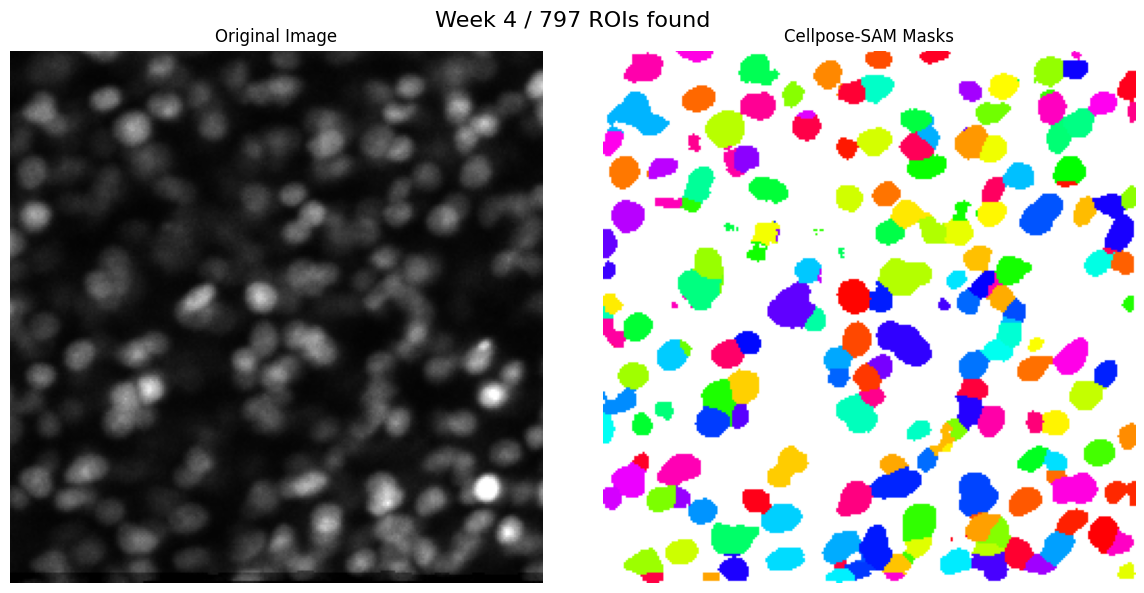

In [34]:
## test cellpose SAM here
from cellpose import models
from cellpose import io as cp_io
from cellpose.io import imread_3D
cp_io.logger_setup()

## use the new Cellpose-SAM model for 3D segmentation, which is trained on 3D images and can handle 3D data directly
model = models.CellposeModel(gpu=True, model_type='cpsam_v2')
loaded_images = imread_3D(output_path)  ## output_path here is the average image of the week, which is a 3D image

masks, flows, styles = model.eval(
    loaded_images,
    do_3D=True,          # Set to True for 3D images
    z_axis = 0,
    channel_axis = 3,
    min_size=100,          # Minimum size of objects to keep
)
# print(f"Segmentation completed. number of ROIs detected: {masks.max()}") # 0 is background, so the number of ROIs is the max value in the mask

## quick vis of the middle slice
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

middle_slice = loaded_images.shape[0] // 2  # Get the middle slice index

ax[0].imshow(loaded_images[middle_slice], cmap='gray',vmin=500,vmax=5000)
ax[0].set_title('Original Image')
ax[0].axis('off')

# # Display masks using an RGB label color format
from cellpose import plot
mask_RGB = plot.mask_overlay(loaded_images[middle_slice], masks[middle_slice])
ax[1].imshow(mask_RGB)
ax[1].set_title('Cellpose-SAM Masks')
ax[1].axis('off')

fig.suptitle(f"Week {week_n} / {masks.max()} ROIs found", fontsize=16)

plt.tight_layout()
plt.show()

## save masks as a tiff file
output_mask_path = Path(output_path).parent / f"{Path(output_path).stem}_cp_masks.tif"

mask_u16 = masks.astype(np.uint16)
tifffile.imwrite(output_mask_path, masks.astype(np.uint16), compression='zlib')

In [30]:
## now, do cellpose 3D on the week average images and come back here afterwards



Similarity between week1_average.tif and week1_average.tif: -1.0
Similarity between week1_average.tif and week2_average.tif: -0.5334508419036865
Similarity between week1_average.tif and week3_average.tif: -0.3264056146144867
Similarity between week1_average.tif and week4_average.tif: -0.20014265179634094
Similarity between week2_average.tif and week2_average.tif: -1.0
Similarity between week2_average.tif and week3_average.tif: -0.636808454990387
Similarity between week2_average.tif and week4_average.tif: -0.41879746317863464
Similarity between week3_average.tif and week3_average.tif: -1.0
Similarity between week3_average.tif and week4_average.tif: -0.6832305192947388
Similarity between week4_average.tif and week4_average.tif: -1.0


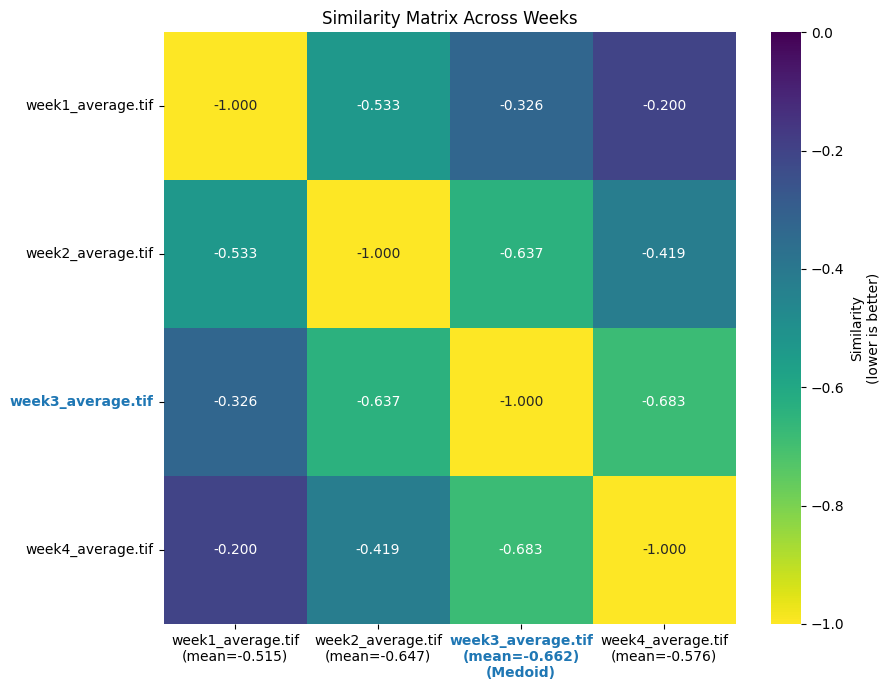

Medoid image for across weeks: week3_average.tif


In [ ]:
## after the average images are done, let's compute the mediod image from the averaged images and then use it as the reference image to match the cell masks
average_file_list = sorted(glob(f"{folder_path}/crop_256/*.tif"))
average_file_list = [f for f in average_file_list if 'average' in f]
average_file_list = [f for f in average_file_list if 'mask' not in f]
average_file_list = [f for f in average_file_list if 'SyN' not in f]

average_file_list

similarity_dict = {}
## loop through all pairs of images in the week and calculate their similarity, including self-similarity (which should be the highest/lowestes in MI)
for a, b in itertools.combinations_with_replacement(average_file_list, 2):
    # print(a.split('/')[-1], b.split('/')[-1])
    a_numpy = io.imread(a)
    b_numpy = io.imread(b)
    a_ants = ants.from_numpy(a_numpy)
    b_ants = ants.from_numpy(b_numpy)
    ## apply quick affine registration first before assessing correlation
    if a == b: # in case that we are comparing the same image, we don't need to register it to itself
        warped_b_ants = b_ants
        similarity = -1.0
    else:
        warped_parms = ants.registration(fixed=a_ants, moving=b_ants, type_of_transform='Affine')
        warped_b_ants = warped_parms['warpedmovout']

        # similarity = ants.image_similarity(a_ants, b_ants, metric_type='MattesMutualInformation')
        similarity = ants.image_similarity(a_ants, warped_b_ants, metric_type='Correlation') 

    print(f"Similarity between {a.split('/')[-1]} and {b.split('/')[-1]}: {similarity}")
    similarity_dict[(a, b)] = similarity

## plot simiarity matrix as a heatmap, with the file names as the x and y labels
import seaborn as sns
import pandas as pd
similarity_matrix = np.zeros((len(average_file_list), len(average_file_list)))
for i, a in enumerate(average_file_list):
    for j, b in enumerate(average_file_list):
        if i == j:
            similarity_matrix[i, j] = similarity_dict[(a, b)]
        elif (a, b) in similarity_dict:
            similarity_matrix[i, j] = similarity_dict[(a, b)]
        elif (b, a) in similarity_dict:
            similarity_matrix[i, j] = similarity_dict[(b, a)]
        else:
            similarity_matrix[i, j] = 0.0

similarity_df = pd.DataFrame(similarity_matrix, index=[Path(f).name for f in average_file_list], columns=[Path(f).name for f in average_file_list])

plt.figure(figsize=(9, 7))
sns.heatmap(similarity_df, annot=True, fmt=".3f", cmap='viridis_r', cbar_kws={'label': 'Similarity\n(lower is better)'},vmin=-1,vmax=0)
plt.title(f"Similarity Matrix Across Weeks")
mean_similarity = np.nanmean(similarity_matrix, axis=1)
# plt.xticks(ticks=np.arange(len(week_list))+0.5, labels=[f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})" for i, f in enumerate(week_list)], rotation=0, ha='center')
plt.yticks(rotation=0)
## highlight the medoid image (the one with the highest average similarity to all other images) by changing the color of its label
medoid_index = np.nanargmin(mean_similarity)
xtick_labels = [
    f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})"
    if i != medoid_index
    else f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})\n(Medoid)"
    for i, f in enumerate(average_file_list)
]
plt.xticks(
    ticks=np.arange(len(average_file_list)) + 0.5,
    labels=xtick_labels,
    rotation=0,
    ha='center'
)
ax = plt.gca()
for idx, label in enumerate(ax.get_xticklabels()):
    if idx == medoid_index:
        label.set_color('C0')
        label.set_fontweight('bold')
for idx, label in enumerate(ax.get_yticklabels()):
    if idx == medoid_index:
        label.set_color('C0')
        label.set_fontweight('bold')
plt.tight_layout()
plt.show()


## find the most similar image to all other images, which is the medoid image of that week
similarity_sums = np.nansum(similarity_matrix, axis=1)
medoid_index = np.nanargmin(similarity_sums) # find the one with the smallest average distance to all other images
medoid_image = average_file_list[medoid_index]
print(f"Medoid image for across weeks: {Path(medoid_image).name}")



In [37]:
## then let's try do SyN registration from all averaged images to the mediod image, and then transform their cp_masks
## perform SyN registration for all images in that week to the medoid image, and save the registered images in the same folder with "_SyN" suffix
medoid_ants = ants.from_numpy(io.imread(medoid_image))
for image_path in average_file_list:
    if image_path == medoid_image:
        ## directly copy the medoid image to the output folder with "_SyN" suffix
        output_path = Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"
        io.imsave(output_path, io.imread(image_path), check_contrast=False)
        print(f"Medoid image copied to: {output_path.name}")
        ## same for green channel
        output_path_g = Path(image_path.replace('_R', '_G')).parent / f"{Path(image_path.replace('_R', '_G')).stem}_SyN.tif"
        io.imsave(output_path_g, io.imread(image_path.replace('_R', '_G')), check_contrast=False)
        print(f"Medoid G channel image copied to: {output_path_g.name}")
        ## same for the masks
        mask_path = image_path.replace("average","average_cp_masks")
        output_fname_mask = Path(mask_path).parent / f"{Path(mask_path).stem}_SyN.tif"
        io.imsave(output_fname_mask, io.imread(mask_path), compression='deflate', photometric="minisblack", check_contrast=False)
        print(f"Medoid mask image copied to: {output_fname_mask.name}")
        continue
    moving_ants = ants.from_numpy(io.imread(image_path))
    reg = ants.registration(fixed=medoid_ants, moving=moving_ants, type_of_transform='SyN')
    registered_ants = reg['warpedmovout']
    registered_numpy = registered_ants.numpy()
    output_path = Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"
    io.imsave(output_path, registered_numpy.astype(np.uint16), check_contrast=False)
    print(f"Registered image saved: {output_path.name}")

    ## and do maks transformation too 
    ## note this is a forward transformation, not inverse
    mask_path = image_path.replace("average","average_cp_masks")
    ROI_mask_ants = ants.from_numpy(io.imread(mask_path))
    warped_ROI_mask = ants.apply_transforms(fixed=moving_ants, moving=ROI_mask_ants, transformlist=reg['fwdtransforms'], interpolator='genericLabel')
    warped_ROI_mask_numpy = warped_ROI_mask.numpy().astype(np.uint16)
    output_fname_mask = Path(mask_path).parent / f"{Path(mask_path).stem}_SyN.tif"
    io.imsave(output_fname_mask, warped_ROI_mask_numpy, compression='deflate', photometric="minisblack", check_contrast=False)
    print(f"Output file saved: {output_fname_mask.name.split('/')[-1]}")


# ## make an average image of all registered images in that week, and save it as "weekX_average.tif"
# registered_images = []
# for image_path in average_file_list:
#     if image_path == medoid_image:
#         registered_images.append(io.imread(image_path))
#     else:
#         registered_images.append(io.imread(Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"))
# average_image = np.nanmean(registered_images, axis=0)
# output_path = Path(folder_path) /"crop_256" / f"grand_average.tif"
# io.imsave(output_path, average_image.astype(np.uint16), check_contrast=False)
# print(f"Average image saved: {output_path.name}")


Registered image saved: week1_average_SyN.tif


/tmp/ipykernel_342945/2665794826.py:35: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(output_fname_mask, warped_ROI_mask_numpy, compression='deflate', photometric="minisblack", check_contrast=False)


Output file saved: week1_average_cp_masks_SyN.tif
Registered image saved: week2_average_SyN.tif


/tmp/ipykernel_342945/2665794826.py:35: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(output_fname_mask, warped_ROI_mask_numpy, compression='deflate', photometric="minisblack", check_contrast=False)


Output file saved: week2_average_cp_masks_SyN.tif
Medoid image copied to: week3_average_SyN.tif
Medoid G channel image copied to: week3_average_SyN.tif


/tmp/ipykernel_342945/2665794826.py:17: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(output_fname_mask, io.imread(mask_path), compression='deflate', photometric="minisblack", check_contrast=False)


Medoid mask image copied to: week3_average_cp_masks_SyN.tif
Registered image saved: week4_average_SyN.tif
Output file saved: week4_average_cp_masks_SyN.tif


/tmp/ipykernel_342945/2665794826.py:35: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(output_fname_mask, warped_ROI_mask_numpy, compression='deflate', photometric="minisblack", check_contrast=False)


In [40]:
## let's load the outputed csv file and see what it looks like now

matched_roi_csv_path = Path(folder_path) /"crop_256" / f"roi_match_runs" / "20260710_test.csv"
matched_roi_csv_path
df_matched_rois = pd.read_csv(matched_roi_csv_path)
df_matched_rois.head(10)

df_matched_rois['n_days_present'].unique()


array([4, 3, 2, 1])

In [ ]:
## okay it seems like that doesn't work so well to perform SyN on the average image
## let's just try ROI mask matching then




In [ ]:
similarity_matrix_after

In [ ]:
## let's compare again the similarity matrix after registration, to see if the similarity has improved and if the medoid image is still the same
## also add the average image to the similarity matrix to see how similar it is to the medoid image and other images in that week

similarity_dict_after = {}
registered_week_list = []
for image_path in week_list:
    if image_path == medoid_image:
        registered_week_list.append(image_path)
    else:
        registered_week_list.append((Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif").as_posix())
registered_week_list.append(output_path.as_posix()) # add the average image to the list for similarity comparison
for a, b in itertools.combinations_with_replacement(registered_week_list, 2):
    # print(a.split('/')[-1], b.split('/')[-1])
    a_numpy = io.imread(a)
    b_numpy = io.imread(b)
    a_ants = ants.from_numpy(a_numpy)
    b_ants = ants.from_numpy(b_numpy)
    # similarity = ants.image_similarity(a_ants, b_ants, metric_type='MattesMutualInformation')
    similarity = -ants.image_similarity(a_ants, b_ants, metric_type='Correlation') ## convert to positive similarity, higher is more similar

    print(f"Similarity between {a.split('/')[-1]} and {b.split('/')[-1]}: {similarity}")
    similarity_dict_after[(a, b)] = similarity
similarity_matrix_after = np.zeros((len(registered_week_list), len(registered_week_list)))
for i, a in enumerate(registered_week_list):
    for j, b in enumerate(registered_week_list):
        if i == j:
            similarity_matrix_after[i, j] = similarity_dict_after[(a, b)]
        elif (a, b) in similarity_dict_after:
            similarity_matrix_after[i, j] = similarity_dict_after[(a, b)]
        elif (b, a) in similarity_dict_after:
            similarity_matrix_after[i, j] = similarity_dict_after[(b, a)]
        else:
            similarity_matrix_after[i, j] = 0.0
similarity_df_after = pd.DataFrame(similarity_matrix_after, index=[Path(f).name.split('_crop')[0] for f in registered_week_list], columns=[Path(f).name.split('_crop')[0] for f in registered_week_list])
plt.figure(figsize=(9, 7))
sns.heatmap(similarity_df_after, annot=True, fmt=".3f", cmap='viridis', cbar_kws={'label': 'Similarity\n(higher is better)'},vmin=0,vmax=1)
plt.title(f"Similarity Matrix for Week {week_n} After Registration")
mean_similarity_after = np.nanmean(similarity_matrix_after, axis=1)
medoid_index_after = np.nanargmax(mean_similarity_after)

xtick_labels_after = [
    f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity_after[i]:.3f})"
    if i != medoid_index_after
    else f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity_after[i]:.3f})\n(Most similar)"
    for i, f in enumerate(registered_week_list)
]
plt.xticks(
    ticks=np.arange(len(registered_week_list)) + 0.5,
    labels=xtick_labels_after,
    rotation=0,
    ha='center'
)
ax = plt.gca()
for idx, label in enumerate(ax.get_xticklabels()):
    if idx == medoid_index_after:
        label.set_color('C0')
        label.set_fontweight('bold')
for idx, label in enumerate(ax.get_yticklabels()):
    if idx == medoid_index_after:
        label.set_color('C0')
        label.set_fontweight('bold')
plt.tight_layout()
plt.show()



In [ ]:
output_path

In [ ]:
medoid_image

In [ ]:
## find the most similar image to all other images, which is the medoid image of that week
similarity_sums = np.nansum(similarity_matrix, axis=1)
medoid_index = np.nanargmin(similarity_sums) # find the one with the smallest average distance to all other images
medoid_image = week_list[medoid_index]
print(f"Medoid image for week {week_n}: {Path(medoid_image).name}")



In [ ]:
np.triu_indices_from(similarity_matrix,k=1)

In [ ]:
np.triu_indices(similarity_matrix)

In [ ]:
up_triangle_idx = np.triu_indices_from(similarity_matrix,k=-)
similarity_matrix[up_triangle_idx] = np.nan

plt.imshow(similarity_matrix, cmap='viridis')

In [ ]:
ants.image_similarity(b_ants, b_ants, metric_type='MattesMutualInformation')